In [114]:
import pandas as pd
import numpy as np

In [115]:
df = pd.read_csv('train.csv')
df. head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [116]:
df.shape

(891, 12)

In [117]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [118]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

# Plotting

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

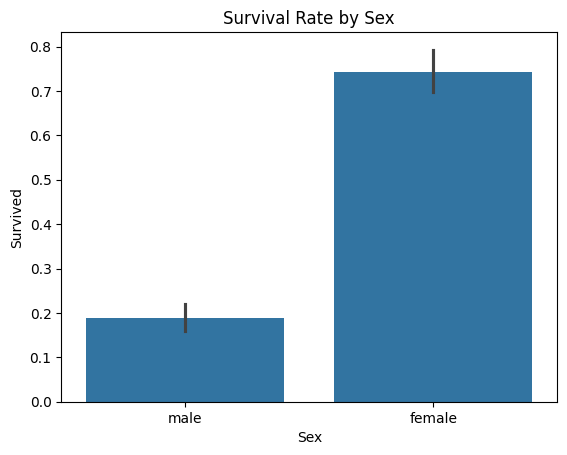

In [120]:
sns.barplot(x = 'Sex', y ='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()

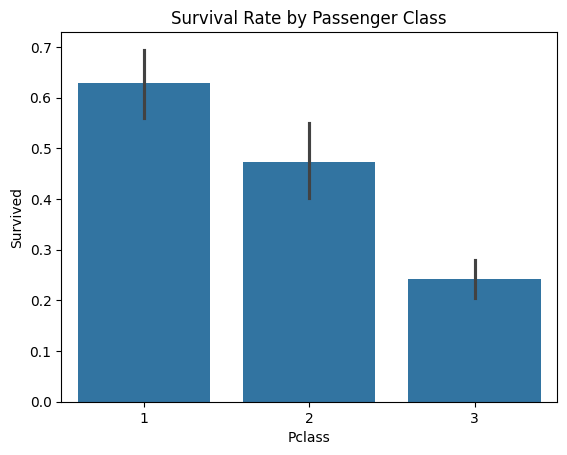

In [121]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.show()

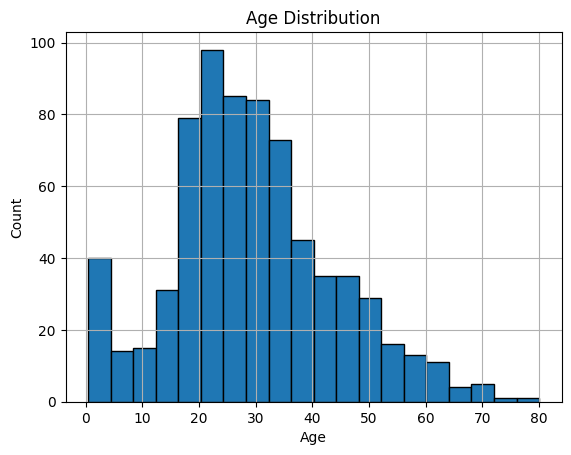

In [122]:
df['Age'].hist(bins=20, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Feature Engineering

In [123]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

In [124]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [125]:
# Family size and IsAlone
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [126]:
# Cabin deck
df['CabinDeck'] = df['Cabin'].str[0]  # first letter
df['CabinDeck'] = df['CabinDeck'].fillna('U')  # U = Unknown

In [127]:
# Ticket group size
ticket_counts = df['Ticket'].value_counts()
df['TicketGroupSize'] = df['Ticket'].map(ticket_counts)

In [128]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')

In [129]:
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace(['Mme'], 'Mrs')
df['Title'] = df['Title'].replace(['Dr', 'Rev', 'Col', 'Major', 'Sir', 'Lady', 'Capt', 'Don', 'Jonkheer', 'Countess'], 'Rare')

In [130]:
from sklearn.preprocessing import LabelEncoder

In [131]:
# Label encoding for tree-based model
label_features = ['Sex', 'Embarked', 'Title', 'CabinDeck']
enc = LabelEncoder()
for col in label_features:
    df[col] = enc.fit_transform(df[col])

In [132]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,CabinDeck,TicketGroupSize,Title
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2,2,0,8,1,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0,2,0,2,1,3
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2,1,1,8,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2,2,0,2,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,2,1,1,8,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,NaN,2,1,1,8,1,4
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,2,1,1,1,1,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,NaN,2,4,0,8,2,1
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,0,1,1,2,1,2


# Selecting feature and target

In [133]:
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked','Title', 'FamilySize', 'IsAlone', 'CabinDeck', 'TicketGroupSize']]
y = df['Survived']

In [134]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [135]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Implementing Models

In [142]:
rf = RandomForestClassifier(
    bootstrap= True,
    criterion='entropy', 
    max_depth= 10,
    max_features='sqrt',
    min_samples_leaf= 1,
    min_samples_split= 5, 
    n_estimators= 10
)

rf.fit(X_train, y_train)

,n_estimators,10
,criterion,'entropy'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [143]:
y_p = rf.predict(X_test)

In [144]:
print("Accuracy:", accuracy_score(y_test, y_p))

Accuracy: 0.8212290502793296


In [145]:
train_pred = rf.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, train_pred))

Train Accuracy: 0.9058988764044944


In [140]:
from sklearn.model_selection import GridSearchCV

In [141]:
param_grid = {
    'n_estimators' : [10, 100, 300],
    'max_depth' : [None, 5, 10, 15],
    'min_samples_split' : [2, 5, 10],
    'max_features' : ['sqrt', 'log2'],
    'min_samples_leaf' : [1, 2, 5],
    'bootstrap' : [True],
    'criterion' : ['gini', 'entropy']
}

clf = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy',n_jobs=-1)
clf.fit(X_train, y_train)
print(clf.best_params_)

{'bootstrap': True, 'criterion': 'entropy', 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 10}
